## Лабораторна робота №3

**Виконали:**
- Сачек Владислава КА-31
- Богданова Олександра КА-32
- Плахтій Злата КА-32

**Хід роботи:**
1. Завантажити початковi данi.
2. Представити данi графiчно.
3. Iнiцiалiзувати параметри: швидкiсть навчання, кiлькiсть епох (=100) i додатково, якщо задано згiдно з варiантом, кiлькiсть пакетiв i/або параметр регуляризацiї.
4. Iнiцiалiзувати вектор параметрiв.
5. Реалiзувати функцiю, яка задає модель, наприклад:
• лiнiйну регресiю,
• полiномiальну регресiю,
• iншу криву, яку пiдiбрати вiдповiдно до заданих даних.
6. Задати функцiю втрат (одну згiдно з варiантом):
• MSE,
• MSE з регуляризацiєю за нормами L1 або L2.
7. Задати операцiю, яка буде викликатися на кожнiй iтерацiї алгоритма
навчання:
• алгоритм стохастичного градiєнтного спуску,
• алгоритм мiнi-пакетного градiєнтного спуску,
• алгоритм стохастичного градiєнтного спуску з моментом,
• алгоритм Adagrad,
• алгоритм Adadelta,
• алгоритм Adam.
8. Виконати навчання моделi.
9. Виводити значення функцiї втрат через кожнi 10 епох.
10. Зберегти контрольнi точки через регулярнi iнтервали пiд час навчання. В кiнцi навчання зберегти результуючу модель. Вiдновити останню контрольну точку при запуску,якщо навчання було перервано.
11. Налаштувати гiперпараметр швидкiсть навчання i додатково, якщо задано згiдно варiанту, розмiр мiнi-пакета. Подивитися на форму кривої навчання.
12. Дослiдити рiзнi значення параметра регуляризацiї i пiдiбрати найкраще з них, якщо згiдно з варiантом задано регуляризовану функцiю втрат. В цьому випадку данi мають бути попередньо розбитi на навчальний та перевiрочний набори.
13. Побудувати графiк з початковими даними та лiнiєю регресiї.

**Варіант 2**

Полiномiальна регресiя, алгоритм градiєнтного спуску за мiнi-батчами, MSE з регуляризацiєю за нормою L2.

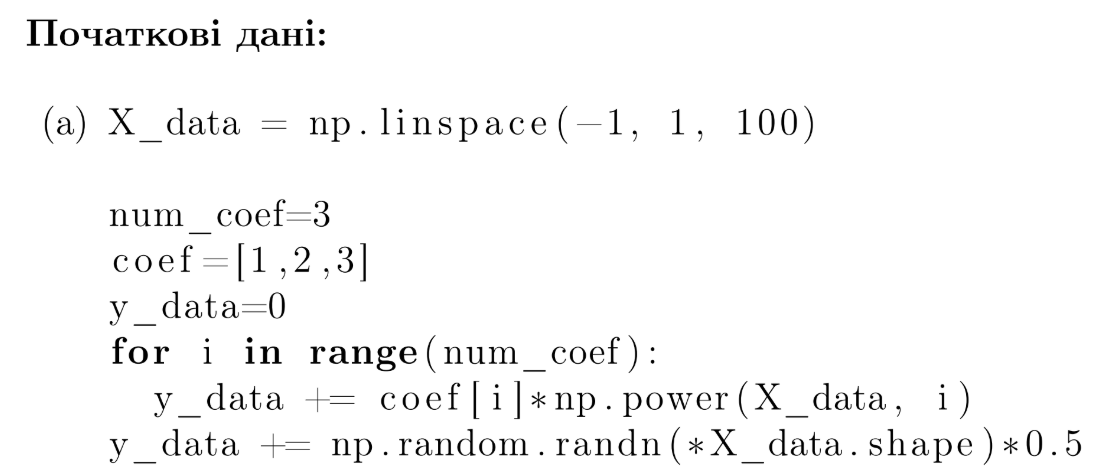

### Генерація даних
Дані генеруються за формулою поліному другого степеня:

**y = 1 + 2x + 3x² + ε**, де ε ~ N(0, 0.5)

Точок: 100, рівномірно на відрізку [-1, 1].

In [28]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

X_data = np.linspace(-1, 1, 100)

num_coef = 3
coef = [1, 2, 3]

y_data = 0
for i in range(num_coef):
    y_data += coef[i] * np.power(X_data, i)

y_data += np.random.randn(*X_data.shape) * 0.5

print("Розмір X:", X_data.shape)
print("Розмір y:", y_data.shape)
print("Перші 5 значень X:", X_data[:5].round(3))
print("Перші 5 значень y:", y_data[:5].round(3))

Розмір X: (100,)
Розмір y: (100,)
Перші 5 значень X: [-1.    -0.98  -0.96  -0.939 -0.919]
Перші 5 значень y: [1.884 1.229 1.978 1.563 1.584]


### Візуалізація даних

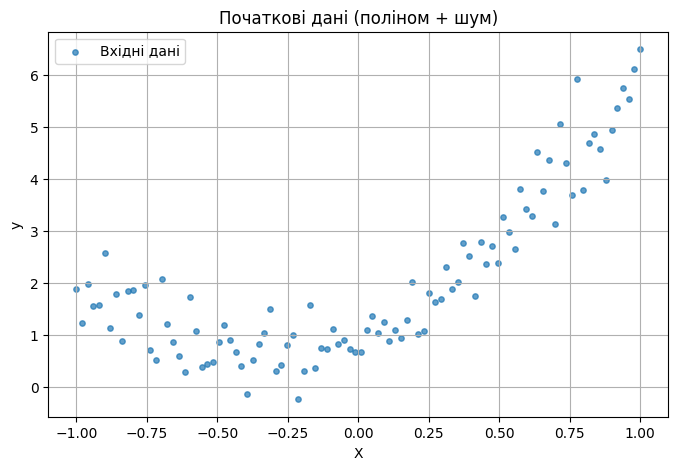

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, s=15, alpha=0.7, label="Вхідні дані")
plt.title("Початкові дані (поліном + шум)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

На графіку видно характерну форму параболи із шумом.
У лівій частині (-1 .. 0) значення y низькі та розкидані,
у правій (0.5 .. 1) — швидко зростають до 5–6.
Це відповідає очікуваній поведінці поліному 1 + 2x + 3x².

### Гіперпараметри

In [30]:
learning_rate = 0.01   
epochs        = 1000    
batch_size    = 20     # розмір міні-батча (100/20 = 5 батчів)
lambda_l2     = 0.001  # параметр L2-регуляризації

### Ініціалізація вектора параметрів та Dataset

Вектор параметрів θ = [w₀, w₁, w₂] розміром (3, 1) ініціалізується
нулями як `tf.Variable` — це навчувані параметри моделі.

`tf.data.Dataset` формується з оригінального вектора X (не розширеного),
перемішується та розбивається на батчі по 20 зразків → 5 батчів на епоху.

In [31]:
# Конвертуємо у тензори
X_tensor = tf.cast(X_data, tf.float32)
y_tensor = tf.cast(y_data, tf.float32)

# Ініціалізація вектора параметрів
theta = tf.Variable(tf.zeros([3, 1], dtype=tf.float32), name="theta")
print("Початкові θ:", theta.numpy().flatten())

# Dataset з оригінальним X (не розширеним)
dataset = tf.data.Dataset.from_tensor_slices((X_tensor, y_tensor))
dataset = dataset.shuffle(buffer_size=100, seed=42).batch(batch_size)

print(f"Кількість батчів: {len(list(dataset))}")

Початкові θ: [0. 0. 0.]
Кількість батчів: 5


### Клас моделі

Клас `PolynomialModel` наслідує `tf.keras.Model`.

Метод `call()` виконує два кроки:
1. Будує матрицю ознак всередині моделі: [1, x, x²] → форма (batch, 3)
2. Обчислює передбачення: ŷ = X_poly @ θ, після чого застосовує
   `tf.squeeze` для приведення форми з (batch, 1) до (batch,) —
   що відповідає формі y і дозволяє коректно обчислити MSE у наступній частині.

In [32]:
class PolynomialModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.theta = theta

    def call(self, x):
        # Будуємо матрицю ознак [1, x, x²] всередині моделі
        X_poly = tf.stack([
            tf.ones_like(x),
            x,
            x ** 2
        ], axis=1)                          # (batch, 3)
        y_pred = tf.matmul(X_poly, self.theta)  # (batch, 1)
        return tf.squeeze(y_pred, axis=1)       # (batch,) 


model = PolynomialModel()

# Перевірка
for X_batch, y_batch in dataset.take(1):
    y_pred = model(X_batch)
    print("Форма батча X     :", X_batch.shape)
    print("Форма батча y     :", y_batch.shape)
    print("Форма передбачення:", y_pred.shape)   
    print("Початкові θ       :", model.theta.numpy().flatten())

Форма батча X     : (20,)
Форма батча y     : (20,)
Форма передбачення: (20,)
Початкові θ       : [0. 0. 0.]


### Функція втрат MSE з L2-регуляризацією
Визначимо за формулою:
$$J(θ) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\|θ\|_2^2,$$

де перший доданок - середньоквадратична помилка MSE, другий - штраф L2 за велику норму вектора параметрів, який стримує зростання параметрів і таким чином запобігає перенавчанню, тобто $J(θ) = MSE + L2Penalty$.   
Використовуємо параметр регуляризації $\lambda$, заданий раніше.

In [33]:
def mse_loss_l2(y_true, y_pred, theta, lambda_l2):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    l2_penalty = lambda_l2 * tf.reduce_sum(tf.square(theta))
    return mse + l2_penalty

### Операція міні-пакетного градієнтного спуску

Створюємо оптимізатор tf.optimizers.SGD із заданим learning_rate = 0.01.
На кожній ітерації:
1. Обчислюємо передбачення моделі на поточному батчі і значення функції втрат (MSE з L2-регуляризацією) усередині tape.
3. За допомогою tf.GradientTape знаходимо градієнти: TensorFlow «розмотує» tape у зворотному напрямку і обчислює ∂J/∂θ.
4. Оновлюємо параметри у напрямку, протилежному градієнту функції втрат: θ <- θ − η * ∇J(θ).

In [34]:
optimizer = tf.optimizers.SGD(learning_rate=learning_rate)

def train_step(model, X_batch, y_batch, lambda_l2):
    with tf.GradientTape() as tape:
        y_pred = model(X_batch)
        loss = mse_loss_l2(y_batch, y_pred, model.theta, lambda_l2)

    gradients = tape.gradient(loss, [model.theta])
    optimizer.apply_gradients(zip(gradients, [model.theta]))
    return loss.numpy()

### Навчання моделі 
На кожній епосі проходимо по всіх 5 батчах датасету, на кожному виконуємо train_step, накопичуємо loss і в кінці рахуємо середній loss за епоху. Кожні 10 епох виводимо значення функцiї втрат.

In [35]:
theta.assign(tf.zeros([3, 1], dtype=tf.float32))

history = []  

for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in dataset:
        batch_loss = train_step(model, X_batch, y_batch, lambda_l2)
        epoch_loss += batch_loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Епоха {epoch:3d}/{epochs}  |  Loss = {avg_loss:.6f}")

print(f"Фінальні θ: {model.theta.numpy().flatten().round(4)}")
print(f"Очікувані:  [1, 2, 3]")

Епоха   1/1000  |  Loss = 6.242152
Епоха  10/1000  |  Loss = 1.965100
Епоха  20/1000  |  Loss = 1.057428
Епоха  30/1000  |  Loss = 0.765024
Епоха  40/1000  |  Loss = 0.615903
Епоха  50/1000  |  Loss = 0.525465
Епоха  60/1000  |  Loss = 0.465558
Епоха  70/1000  |  Loss = 0.422614
Епоха  80/1000  |  Loss = 0.390661
Епоха  90/1000  |  Loss = 0.365307
Епоха 100/1000  |  Loss = 0.345276
Епоха 110/1000  |  Loss = 0.328464
Епоха 120/1000  |  Loss = 0.314799
Епоха 130/1000  |  Loss = 0.303456
Епоха 140/1000  |  Loss = 0.293231
Епоха 150/1000  |  Loss = 0.285373
Епоха 160/1000  |  Loss = 0.278121
Епоха 170/1000  |  Loss = 0.272525
Епоха 180/1000  |  Loss = 0.267374
Епоха 190/1000  |  Loss = 0.263237
Епоха 200/1000  |  Loss = 0.259566
Епоха 210/1000  |  Loss = 0.256614
Епоха 220/1000  |  Loss = 0.254206
Епоха 230/1000  |  Loss = 0.252001
Епоха 240/1000  |  Loss = 0.250139
Епоха 250/1000  |  Loss = 0.248713
Епоха 260/1000  |  Loss = 0.247300
Епоха 270/1000  |  Loss = 0.246211
Епоха 280/1000  |  L

На першій епосі loss = 6.24, далі швидко падає — вже на 100-й епосі досягає 0.345,
після чого спадання уповільнюється. На 1000-й епосі loss = 0.240.

Фінальні θ = [0.9785, 2.0303, 3.0806] дуже близькі до очікуваних [1, 2, 3] —
максимальне відхилення становить лише 0.08 (для θ₂).

#### Крива навчання

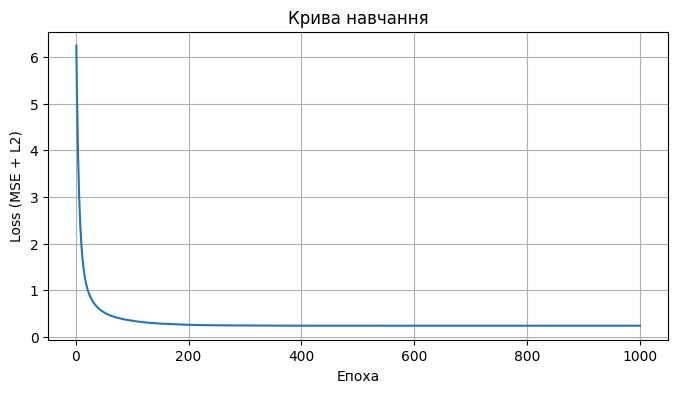

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), history, linewidth=1.5)
plt.xlabel("Епоха")
plt.ylabel("Loss (MSE + L2)")
plt.title("Крива навчання")
plt.grid(True)
plt.show()

Крива навчання має форму спадної експоненти — loss монотонно спадає протягом
усіх 1000 епох. Найінтенсивніше падіння відбувається в перших ~100 епохах
(з 6.24 до 0.345), після чого крива виполажується і поступово наближається
до значення ~0.24.

### Checkpoint-система

Зберігаємо контрольні точки кожні 10 епох під час навчання за допомогою
tf.train.CheckpointManager. При повторному запуску — автоматично відновлюємо
навчання з останньої збереженої точки.

1. Створюємо об'єкт tf.train.Checkpoint, який відстежує theta та optimizer.
2. CheckpointManager зберігає не більше 5 останніх точок у папці ./checkpoints.
3. На початку перевіряємо, чи є збережений checkpoint — якщо є, відновлюємо θ
   і продовжуємо навчання з відповідної епохи.
4. Після завершення навчання зберігаємо фінальну модель у ./final_model.

In [37]:
import os

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_interval = 10  

ckpt = tf.train.Checkpoint(theta=theta, optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(
    ckpt,
    directory=checkpoint_dir,
    max_to_keep=5
)

start_epoch = 1
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    ckpt_num = int(ckpt_manager.latest_checkpoint.split("-")[-1])
    start_epoch = ckpt_num * checkpoint_interval + 1
    print(f"Відновлено з: {ckpt_manager.latest_checkpoint}")
    print(f"Продовжуємо з епохи {start_epoch}")
    print(f"θ = {theta.numpy().flatten().round(4)}")
else:
    print("Checkpoint не знайдено. Навчання з початку.")
    theta.assign(tf.zeros([3, 1], dtype=tf.float32))

history = []

for epoch in range(start_epoch, epochs + 1):
    epoch_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in dataset:
        batch_loss = train_step(model, X_batch, y_batch, lambda_l2)
        epoch_loss += batch_loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Епоха {epoch:3d}/{epochs}  |  Loss = {avg_loss:.6f}")

    if epoch % checkpoint_interval == 0:
        save_path = ckpt_manager.save(
            checkpoint_number=epoch // checkpoint_interval
        )
        print(f"Checkpoint збережено: {save_path}")

final_model_dir = "./final_model"
os.makedirs(final_model_dir, exist_ok=True)
model.save_weights(os.path.join(final_model_dir, "model_weights.weights.h5"))

print(f"\nФінальна модель збережена у '{final_model_dir}/model_weights.weights.h5'")
print(f"Фінальні θ: {model.theta.numpy().flatten().round(4)}")
print(f"Очікувані:  [1, 2, 3]")

Відновлено з: ./checkpoints\ckpt-50
Продовжуємо з епохи 501
θ = [1.0704 1.9469 2.8333]
Епоха 510/1000  |  Loss = 0.246977
Checkpoint збережено: ./checkpoints\ckpt-51
Епоха 520/1000  |  Loss = 0.245235
Checkpoint збережено: ./checkpoints\ckpt-52
Епоха 530/1000  |  Loss = 0.244526
Checkpoint збережено: ./checkpoints\ckpt-53
Епоха 540/1000  |  Loss = 0.243414
Checkpoint збережено: ./checkpoints\ckpt-54
Епоха 550/1000  |  Loss = 0.243115
Checkpoint збережено: ./checkpoints\ckpt-55
Епоха 560/1000  |  Loss = 0.242240
Checkpoint збережено: ./checkpoints\ckpt-56
Епоха 570/1000  |  Loss = 0.241960
Checkpoint збережено: ./checkpoints\ckpt-57
Епоха 580/1000  |  Loss = 0.242274
Checkpoint збережено: ./checkpoints\ckpt-58
Епоха 590/1000  |  Loss = 0.241486
Checkpoint збережено: ./checkpoints\ckpt-59
Епоха 600/1000  |  Loss = 0.241211
Checkpoint збережено: ./checkpoints\ckpt-60
Епоха 610/1000  |  Loss = 0.241534
Checkpoint збережено: ./checkpoints\ckpt-61
Епоха 620/1000  |  Loss = 0.241139
Checkpoin

Checkpoint-система відпрацювала коректно: при повторному запуску було відновлено
стан з ckpt-50 (епоха 500, θ = [1.0704, 1.9469, 2.8333]) і навчання продовжилось
з епохи 501. Checkpoints зберігались кожні 10 епох (ckpt-51 — ckpt-100),
у папці зберігаються лише останні 5. Фінальну модель збережено у
./final_model/model_weights.weights.h5.

### Налаштування гіперпараметрів
Досліджуємо вплив швидкості навчання та розміру міні-батча на форму кривої
навчання. Для кожної комбінації навчаємо модель з нуля і порівнюємо криві.

Перевіряємо такі значення:
- learning_rate ∈ {0.001, 0.01, 0.05, 0.1}
- batch_size ∈ {10, 20, 50}

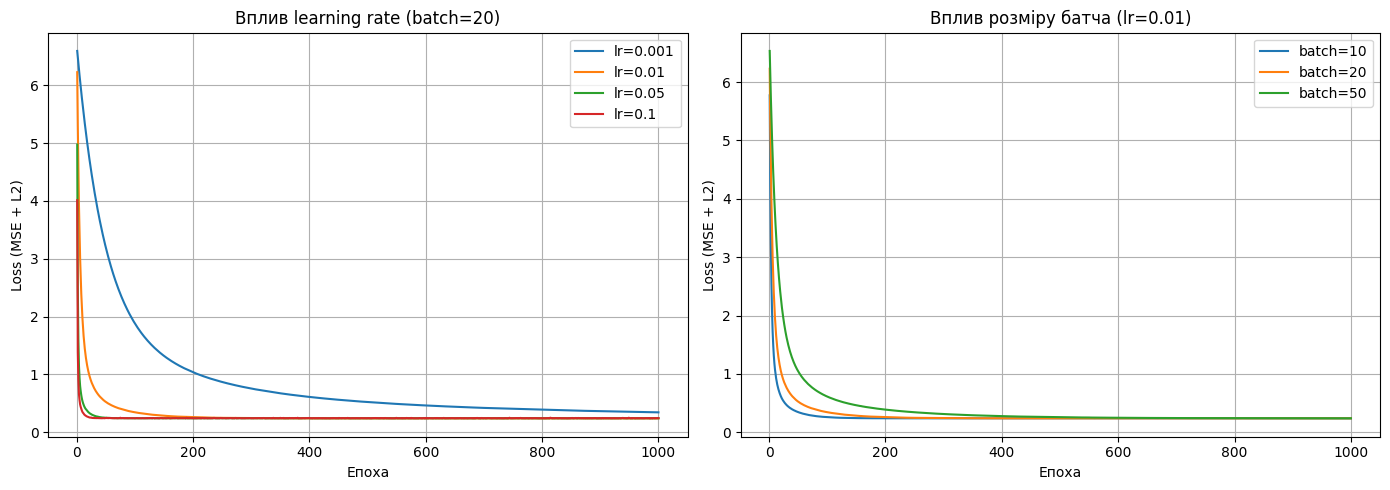

In [38]:
lr_values    = [0.001, 0.01, 0.05, 0.1]
batch_values = [10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Вплив learning rate
for lr in lr_values:
    theta_tmp = tf.Variable(tf.zeros([3, 1], dtype=tf.float32))

    class TmpModel(tf.keras.Model):
        def __init__(self):
            super().__init__()
            self.theta = theta_tmp
        def call(self, x):
            X_poly = tf.stack([tf.ones_like(x), x, x**2], axis=1)
            return tf.squeeze(tf.matmul(X_poly, self.theta), axis=1)

    m = TmpModel()
    opt = tf.optimizers.SGD(learning_rate=lr)
    ds  = tf.data.Dataset.from_tensor_slices(
        (tf.cast(X_data, tf.float32), tf.cast(y_data, tf.float32))
    ).shuffle(100, seed=42).batch(20)

    hist = []
    for epoch in range(epochs):
        el = 0.0
        nb = 0
        for Xb, yb in ds:
            with tf.GradientTape() as tape:
                yp   = m(Xb)
                loss = mse_loss_l2(yb, yp, m.theta, lambda_l2)
            grads = tape.gradient(loss, [m.theta])
            opt.apply_gradients(zip(grads, [m.theta]))
            el += loss.numpy(); nb += 1
        hist.append(el / nb)

    axes[0].plot(range(1, epochs + 1), hist, label=f"lr={lr}")

axes[0].set_title("Вплив learning rate (batch=20)")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss (MSE + L2)")
axes[0].legend()
axes[0].grid(True)

# Вплив batch_size 
for bs in batch_values:
    theta_tmp = tf.Variable(tf.zeros([3, 1], dtype=tf.float32))

    class TmpModel2(tf.keras.Model):
        def __init__(self):
            super().__init__()
            self.theta = theta_tmp
        def call(self, x):
            X_poly = tf.stack([tf.ones_like(x), x, x**2], axis=1)
            return tf.squeeze(tf.matmul(X_poly, self.theta), axis=1)

    m = TmpModel2()
    opt = tf.optimizers.SGD(learning_rate=0.01)
    ds  = tf.data.Dataset.from_tensor_slices(
        (tf.cast(X_data, tf.float32), tf.cast(y_data, tf.float32))
    ).shuffle(100, seed=42).batch(bs)

    hist = []
    for epoch in range(epochs):
        el = 0.0
        nb = 0
        for Xb, yb in ds:
            with tf.GradientTape() as tape:
                yp   = m(Xb)
                loss = mse_loss_l2(yb, yp, m.theta, lambda_l2)
            grads = tape.gradient(loss, [m.theta])
            opt.apply_gradients(zip(grads, [m.theta]))
            el += loss.numpy(); nb += 1
        hist.append(el / nb)

    axes[1].plot(range(1, epochs + 1), hist, label=f"batch={bs}")

axes[1].set_title("Вплив розміру батча (lr=0.01)")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Loss (MSE + L2)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Вплив learning rate (batch=20): більший lr — швидша збіжність. lr=0.001 не сходиться за 100 епох, lr=0.05 і lr=0.1 стабілізуються вже на 15-й епосі.

Вплив розміру батча (lr=0.01): менший батч — частіші оновлення параметрів
і швидша збіжність. batch=10 сходиться найшвидше, batch=50 — найповільніше.

### Підбір параметра регуляризації L2
Оскількизадана MSE з L2-регуляризацією, необхідно  підібрати оптимальне значення параметра λ.

1. Розбиваємо дані на навчальний (80%) та перевірочний (20%) набори.
2. Навчаємо модель для кожного λ з набору {0.0, 0.0001, 0.001, 0.01, 0.1, 1.0}.
3. Оцінюємо якість на перевірочному наборі за чистим MSE (без штрафу).
4. Обираємо λ з найменшим validation MSE.

Train: 80 зразків  |  Val: 20 зразків
λ = 0.0000  →  Val MSE = 0.199540  |  θ = [1.0153 2.037  3.0299]
λ = 0.0001  →  Val MSE = 0.199721  |  θ = [1.0161 2.0365 3.0272]
λ = 0.0010  →  Val MSE = 0.201366  |  θ = [1.0235 2.0321 3.0032]
λ = 0.0100  →  Val MSE = 0.219559  |  θ = [1.0885 1.9886 2.7869]
λ = 0.1000  →  Val MSE = 0.404823  |  θ = [1.3304 1.6195 1.746 ]
λ = 1.0000  →  Val MSE = 1.572142  |  θ = [0.9448 0.5587 0.5776]

Найкраще λ = 0.0  (Val MSE = 0.199540)


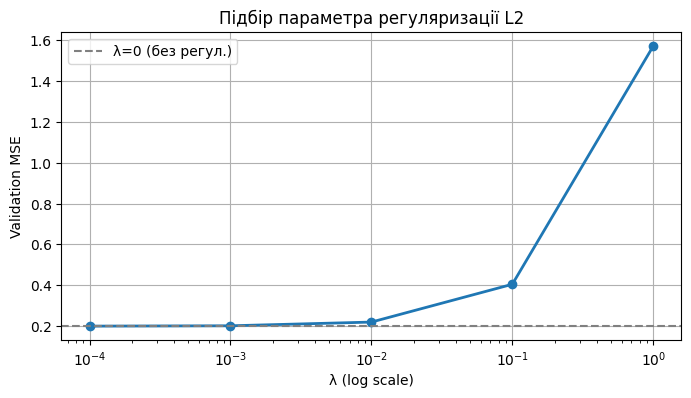

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

X_train_t = tf.cast(X_train, tf.float32)
y_train_t = tf.cast(y_train, tf.float32)
X_val_t   = tf.cast(X_val,   tf.float32)
y_val_t   = tf.cast(y_val,   tf.float32)

print(f"Train: {len(X_train)} зразків  |  Val: {len(X_val)} зразків")

lambda_values = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]
val_results   = {}

for lam in lambda_values:
    theta_tmp = tf.Variable(tf.zeros([3, 1], dtype=tf.float32))

    class LamModel(tf.keras.Model):
        def __init__(self):
            super().__init__()
            self.theta = theta_tmp
        def call(self, x):
            X_poly = tf.stack([tf.ones_like(x), x, x**2], axis=1)
            return tf.squeeze(tf.matmul(X_poly, self.theta), axis=1)

    m   = LamModel()
    opt = tf.optimizers.SGD(learning_rate=learning_rate)
    ds  = tf.data.Dataset.from_tensor_slices(
        (X_train_t, y_train_t)
    ).shuffle(200, seed=42).batch(batch_size)

    for epoch in range(epochs):
        for Xb, yb in ds:
            with tf.GradientTape() as tape:
                yp   = m(Xb)
                loss = mse_loss_l2(yb, yp, m.theta, lam)
            grads = tape.gradient(loss, [m.theta])
            opt.apply_gradients(zip(grads, [m.theta]))

    y_val_pred = m(X_val_t)
    val_mse    = tf.reduce_mean(tf.square(y_val_t - y_val_pred)).numpy()
    val_results[lam] = val_mse
    print(f"λ = {lam:.4f}  →  Val MSE = {val_mse:.6f}  |  θ = {m.theta.numpy().flatten().round(4)}")

best_lambda = min(val_results, key=val_results.get)
print(f"\nНайкраще λ = {best_lambda}  (Val MSE = {val_results[best_lambda]:.6f})")

plt.figure(figsize=(8, 4))
lambdas_nonzero = [l for l in lambda_values if l > 0]
vals_nonzero    = [val_results[l] for l in lambdas_nonzero]

plt.semilogx(lambdas_nonzero, vals_nonzero, 'o-', linewidth=2)
plt.axhline(val_results[0.0], color='gray', linestyle='--', label='λ=0 (без регул.)')
plt.xlabel("λ (log scale)")
plt.ylabel("Validation MSE")
plt.title("Підбір параметра регуляризації L2")
plt.legend()
plt.grid(True)
plt.show()

При 1000 епохах найкраще значення λ = 0.0 (Val MSE = 0.1995) — модель достатньо
добре збігається без штрафу. Малі значення λ = 0.0001–0.001 дають схожий
результат, λ = 0.01 вже помітно погіршує якість. Великі значення (0.1, 1.0)
сильно стримують параметри і дають неприйнятний результат.

## Графік початкових даних та лінії регресії

Будуємо фінальний графік: початкові дані (scatter) та крива,
яку передбачає навчена модель на щільній сітці точок від -1 до 1.
Також виводимо знайдені параметри θ та порівнюємо з очікуваними.

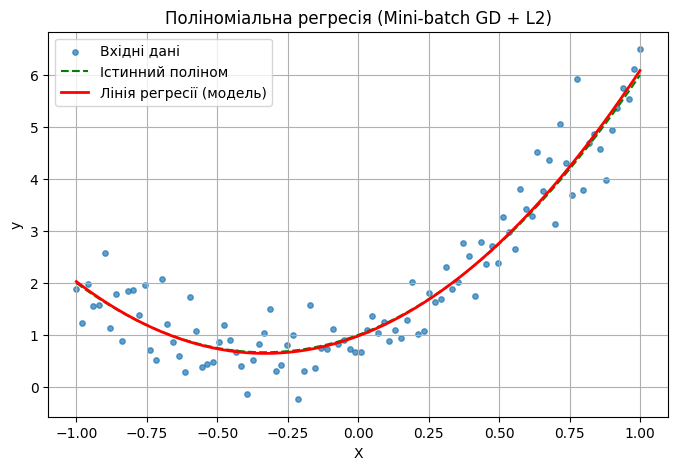

Знайдені θ: [0.9797 2.0304 3.0774]
Очікувані: [1, 2, 3]
Відхилення: [-0.0203  0.0304  0.0774]


In [40]:
X_plot  = np.linspace(-1, 1, 200).astype(np.float32)
y_plot  = model(X_plot).numpy()

# Очікувана крива (без шуму)
y_true_curve = 1 + 2*X_plot + 3*X_plot**2

plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, s=15, alpha=0.7, label="Вхідні дані")
plt.plot(X_plot, y_true_curve, 'g--', linewidth=1.5, label="Істинний поліном")
plt.plot(X_plot, y_plot,       'r-',  linewidth=2,   label="Лінія регресії (модель)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Поліноміальна регресія (Mini-batch GD + L2)")
plt.legend()
plt.grid(True)
plt.show()

theta_final = model.theta.numpy().flatten().round(4)
print(f"Знайдені θ: {theta_final}")
print(f"Очікувані: [1, 2, 3]")
print(f"Відхилення: {(theta_final - np.array([1., 2., 3.])).round(4)}")

Лінія регресії (червона) добре відтворює форму параболи і практично збігається
з істинним поліномом (зелена) на всьому відрізку [-1, 1].

Знайдені θ = [0.9797, 2.0304, 3.0774] відхиляються від очікуваних [1, 2, 3]
лише на [-0.02, 0.03, 0.08] — значно краще порівняно з результатом при
100 епохах, де відхилення сягало 1.04 для θ₂.

### Висновки

У лабораторній роботі реалізовано поліноміальну регресію другого степеня
методом міні-пакетного градієнтного спуску з L2-регуляризацією засобами TensorFlow.

Основні результати:
- модель успішно апроксимує залежність y = 1 + 2x + 3x² з шумом — лінія
  регресії практично збігається з істинним поліномом на всьому відрізку [-1, 1]
- checkpoint-система коректно зберігає стан навчання кожні 10 епох і відновлює
  його при повторному запуску (відновлено з ckpt-50, продовжено з епохи 501)
- при підборі λ з'ясовано, що при 1000 епохах найкращий результат дає λ = 0.0
  (Val MSE = 0.1995) — модель збігається без регуляризації; значення λ ≥ 0.1
  суттєво погіршують якість
- збільшення learning rate та зменшення розміру батча прискорюють збіжність:
  lr=0.1 стабілізується вже на ~15-й епосі, batch=10 сходиться швидше за batch=50
- збільшення кількості епох із 100 до 1000 суттєво підвищило точність параметрів:

  | Епохи | θ₀     | θ₁     | θ₂     | Середнє відхилення |
  |-------|--------|--------|--------|--------------------|
  | 100   | 1.4229 | 1.761  | 1.9554 | 0.302              |
  | 500   | 1.0704 | 1.9469 | 2.8333 | 0.097              |
  | 1000  | 0.9797 | 2.0304 | 3.0774 | 0.043              |

  Знайдені θ = [0.9797, 2.0304, 3.0774] є найближчими до очікуваних [1, 2, 3].
  Залишкове відхилення пояснюється шумом у даних (ε ~ N(0, 0.5)).